# Solar Wind Dataset EDA

This notebook explores the `juliensimon/solar-wind` dataset for the geomagnetic storm prediction project.

The goal of this EDA is to:
- understand what the dataset represents
- inspect the columns and data types
- check missing values
- identify possible outliers
- create basic visualizations for useful variables
- note potential features for predicting geomagnetic storms

## Dataset Background

This dataset contains real-time solar wind plasma and magnetic field measurements from the DSCOVR and ACE spacecraft at the L1 Lagrange point. The measurements are collected upstream of Earth, meaning they can provide short lead-time information before solar wind reaches Earth's magnetosphere. 

The dataset is relevant to geomagnetic storm prediction because solar wind speed, density, and magnetic field orientation are major drivers of geomagnetic activitiy. In particular, the `bz_gsm` variable is important because sustained negative Bz indicates a southward interplanetary magnetic field, which can couple with Earth's magnetosphere and trigger geomagnetic storms. 

This dataset may help connect solar activity to geomagnetic storm outcomes in the broader causal chain:

solar flare -> CME -> solar wind -> geomagnetic indices/storms

### Plain-english Initial Understanding

The dataset is the solar wind dataset. It contains around one-minute measurements of solar wind plasma and magnetic field conditions from spacecraft located at the L1 point, between the Sun and Earth. This is useful because it captures the solar wind shortly before it reaches Earth's magnetosphere. The key variables include density, speed, temperature, total magnetic field strength, and magnetic field components in GSM coordinates. Among these, Bz is especially important because sustained negative Bz can allow stronger coupling with Earth's magnetic field and contribute to geomagnetic storms. 

**Important Note: dataset is updated daily, so row count may differ from the dataset card preview.**

## Research Notes / Terms to Understand

Because our group is still building background knowledge in space weather, this EDA will document unfamiliar variables, units, and scientific concepts as we inspect the dataset. 

Terms that may need further research:
- solar wind
- DSCOVR
- ACE
- L1 Lagrange point
- IMF
- GSM coordinates
- Bx, By, Bz
- southward Bz
- magnetic reconnection
- Kp index
- Dst index

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# install hugging face datasets if neededz
%pip install datasets -q
from datasets import load_dataset


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
dataset = load_dataset("juliensimon/solar-wind")
dataset

README.md: 0.00B [00:00, ?B/s]

data/solar_wind.parquet:   0%|          | 0.00/2.73M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/123316 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['time_tag', 'density', 'speed', 'temperature', 'bt', 'bx_gsm', 'by_gsm', 'bz_gsm'],
        num_rows: 123316
    })
})

In [5]:
ds = dataset["train"]
df = ds.to_pandas()

df.head()

,time_tag,density,speed,temperature,bt,bx_gsm,by_gsm,bz_gsm
0,2026-03-17 08:31:00,0.38,467.8,57895.0,4.49,-3.47,2.74,-0.79
1,2026-03-17 08:32:00,0.41,471.6,71499.0,4.58,-3.38,3.08,-0.21
2,2026-03-17 08:33:00,0.42,472.1,76974.0,4.39,-3.21,2.99,-0.10
3,2026-03-17 08:34:00,0.45,465.1,51641.0,4.27,-3.45,2.47,-0.47
4,2026-03-17 08:35:00,0.95,489.6,103878.0,4.39,-3.49,2.63,-0.33


In [6]:
df.shape

(123316, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123316 entries, 0 to 123315
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   time_tag     123316 non-null  datetime64[ns]
 1   density      119945 non-null  float64       
 2   speed        119443 non-null  float64       
 3   temperature  118866 non-null  float64       
 4   bt           120882 non-null  float64       
 5   bx_gsm       120882 non-null  float64       
 6   by_gsm       120882 non-null  float64       
 7   bz_gsm       120882 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 7.5 MB


## Column Dictionary

| Column | Type | Meaning | Unit / Notes | Initial modeling relevance |
|---|---|---|---|---|
| `time_tag` | datetime | Measurement timestamp from DSCOVR/ACE at the L1 Lagrange point | UTC, approximately 1-minute cadence | Needed for time-based merging with storm labels or geomagnetic indices |
| `density` | numerical | Solar wind proton number density | protons/cm³ | Higher density can increase solar wind dynamic pressure on Earth's magnetosphere |
| `speed` | numerical | Solar wind bulk velocity | km/s | High solar wind speed can be associated with stronger geomagnetic activity |
| `temperature` | numerical | Solar wind proton temperature | Kelvin | May help identify solar wind structures such as magnetic clouds or CME-related conditions |
| `bt` | numerical | Total interplanetary magnetic field magnitude | nT | Stronger magnetic field can indicate more geoeffective solar wind conditions |
| `bx_gsm` | numerical | IMF Bx component in GSM coordinates | nT | Magnetic field component in the Sun-Earth direction |
| `by_gsm` | numerical | IMF By component in GSM coordinates | nT | May relate to asymmetric magnetospheric convection/current systems |
| `bz_gsm` | numerical | IMF Bz component in GSM coordinates | nT | Key storm driver; sustained negative/southward Bz can couple with Earth's magnetosphere |

In [8]:
# column summary table
column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "unique_count": df.nunique().values
})

column_summary

,column,dtype,non_null_count,missing_count,missing_percent,unique_count
0,time_tag,datetime64[ns],123316,0,0.00,123316
1,density,float64,119945,3371,2.73,2509
2,speed,float64,119443,3873,3.14,4738
3,temperature,float64,118866,4450,3.61,90103
4,bt,float64,120882,2434,1.97,2621
5,bx_gsm,float64,120882,2434,1.97,3013
6,by_gsm,float64,120882,2434,1.97,3746
7,bz_gsm,float64,120882,2434,1.97,3123


## Initial Observations

- The dataset has one datetime column (`time_tag`) and seven numerical columns.
- `time_tag` has no missing values, which is important because this dataset will likely need to be merged with storm lables or geomagnetic indices by timestamp.
- All solar wind measurement columns have some missing values.
- Magnetic field columns (`bt`, `bx_gsm`, `by_gsm`, `bz_gsm`) appear to have the same non-null count, suggesting they may come from the same instrument/source or be missing together. 
- Plasma varaibles (`density`, `speed`, `temperature`) have slightly different missingness patterns.
- Since the dataset is updated daily, row count may differ from the dataset card preview.

## Plain-English Understanding

This dataset represents solar wind conditions measured shortly before the solar wind reaches Earth. The spacecraft are located at the L1 point between the Sun and Earth, so the dataset can provide short lead-time information for geomagnetic storm prediction.

In simple terms, the variables describe:
- how dense the solar wind is (`density`)
- how fast it is moving (`speed`)
- how hot the plasma is (`temperature`)
- how strong the magnetic field is overall (`bt`)
- which direction the magnetic field points (`bx_gsm`, `by_gsm`, `bz_gsm`)

The most important variable appears to be `bz_gsm`. When Bz is negative, the solar wind magnetic field points southward. This can connect more strongly with Earth's magnetic field and transfer energy into Earth's magnetosphere, which can contribute to geomagnetic storms. 


## Missing Values

This section checks how much missing data exists in each column. Since this dataset is time-series data, missing values may represent gaps in instrument readings or data availability. We first summarize missing values by column, then later check whether missing values occur at specific times or in groups. 

In [9]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "non_missing_count": df.notna().sum().values
})

missing_values.sort_values("missing_percent", ascending=False)

,column,missing_count,missing_percent,non_missing_count
3,temperature,4450,3.61,118866
2,speed,3873,3.14,119443
1,density,3371,2.73,119945
4,bt,2434,1.97,120882
5,bx_gsm,2434,1.97,120882
6,by_gsm,2434,1.97,120882
7,bz_gsm,2434,1.97,120882
0,time_tag,0,0.00,123316


In [10]:
# since bt, bx_gsm, by_gsm, bz_gsm have all same non-null count
magnetic_cols = ["bt", "bx_gsm", "by_gsm", "bz_gsm"]
plasma_cols = ["density", "speed", "temperature"]

df[magnetic_cols].isna().sum()

bt        2434
bx_gsm    2434
by_gsm    2434
bz_gsm    2434
dtype: int64

In [11]:
df[plasma_cols].isna().sum()

density        3371
speed          3873
temperature    4450
dtype: int64

In [12]:
df["missing_magnetic_count"] = df[magnetic_cols].isna().sum(axis=1)
df["missing_plasma_count"] = df[plasma_cols].isna().sum(axis=1)

df[["missing_magnetic_count", "missing_plasma_count"]].value_counts().sort_index()

missing_magnetic_count  missing_plasma_count
0                       0                       116464
                        1                          569
                        2                          481
                        3                         3368
4                       0                         2399
                        1                           11
                        2                           24
Name: count, dtype: int64

### Missing Values Observations

- `time_tag` has no missing values, which is important because the dataset will likely need to be merged with geomagnetic storm labels or indices by timestamp.
- All seven measurement variables have some missing values, but the overall missing percentages are relatively low.
- `temperature` has the highest missing rate at 3.61%, followed by `speed` at 3.14% and `density` at 2.73%.
- The magnetic field variables (`bt`, `bx_gsm`, `by_gsm`, `bz_gsm`) each have 2,434 missing values, or 1.97% of the dataset.
- The missing pattern suggests that the magnetic field variables are missing together: rows have either 0 missing magnetic variables or all 4 missing magnetic variables.
- Plasma variables (`density`, `speed`, `temperature`) have more varied missing patterns, with some rows missing one, two, or all three plasma variables. 
- Since this is time-series sensor data, missing values may represent temporary instrument or data availability gaps rather than random missingness.

## Summary Statistics

This section summarizes the numerical variables in the solar wind dataset. These statistics help us understand the typical range, spread, and extreme values for each measurement variable before creating visualizations or checking outliers. 

In [13]:
numeric_cols = ["density", "speed", "temperature", "bt", "bx_gsm", "by_gsm", "bz_gsm"]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
density,119945.0,3.261069,3.592914,0.00,1.37,2.44,3.97,190.63
speed,119443.0,451.406838,87.462299,270.10,387.60,434.80,503.60,1232.70
temperature,118866.0,110490.570171,98663.983034,2000.00,49795.00,85443.50,136461.50,3573881.00
bt,120882.0,6.240415,3.521123,0.20,4.25,5.19,7.08,38.97
bx_gsm,120882.0,0.233585,4.049563,-33.83,-2.60,0.82,2.98,16.12
by_gsm,120882.0,-0.475905,4.570263,-34.40,-3.34,-0.58,2.46,24.63
bz_gsm,120882.0,0.060327,3.702472,-27.95,-2.12,0.00,2.13,31.43


### Summary Statistics Observations

- Most variables have typical central values that appear reasonable based on the dataset description.
- `speed` has a median of 434.8 km/s and mean of 451.4 km/s, which is close to typical quiet-to-moderate solar wind speeds.
- `density` has a median of 2.44 protons/cm^3 and mean of 3.26 protons/cm^3, but the maximum value is 190.63, suggesting possible extreme readings or outliers.
- `temperature` is highly spread out, with a median of 85,443.5 K and a maximum of 3,573,881 K. This suggests a right-skewed distribution.
- `bt` has a median of 5.19 nT, within the typical quiet-time magnetic field range, but reaches a maximum of 38.97 nT during stronger magnetic field conditions.
- `bz_gsm` ranges from -27.95 nT to 31.43 nT. Since negative Bz is important for geomagnetic storm coupling, the minimum Bz value is especially relevant for further analysis.
- Several variables have extreme maximum or minimum values, so later outlier checks should distinguish between possible data errors and physically meaningful space weather event. 

## Time Range and Cadence

This section checks the time coverage of the dataset and whether measurements follow the expected approximately 1-minute cadence. Since this dataset may later be merged with geomagnetic storm labels or indices, timestamp completeness and time gaps are important.

In [16]:
df["time_tag"].min(), df["time_tag"].max()

(Timestamp('2026-03-17 08:31:00'), Timestamp('2026-06-11 18:13:00'))

In [17]:
df["time_tag"].max() - df["time_tag"].min()

Timedelta('86 days 09:42:00')

In [19]:
df_sorted = df.sort_values("time_tag").copy()
df_sorted["time_diff"] = df_sorted["time_tag"].diff()
df_sorted["time_diff"].value_counts().head(10)

time_diff
0 days 00:01:00    122832
0 days 00:02:00       407
0 days 00:03:00        34
0 days 00:04:00        24
0 days 00:05:00         4
0 days 00:15:00         2
0 days 00:06:00         2
0 days 00:10:00         2
0 days 00:42:00         1
0 days 00:26:00         1
Name: count, dtype: int64

In [20]:
time_gaps = df_sorted[df_sorted["time_diff"] > pd.Timedelta(minutes=1)][
    ["time_tag", "time_diff"]
].copy()

time_gaps.sort_values("time_diff", ascending=False).head(10)

,time_tag,time_diff
110940,2026-06-03 03:02:00,0 days 05:30:00
1177,2026-03-18 04:53:00,0 days 00:42:00
120255,2026-06-09 14:55:00,0 days 00:33:00
8829,2026-03-23 13:59:00,0 days 00:27:00
8825,2026-03-23 13:29:00,0 days 00:26:00
90708,2026-05-19 18:20:00,0 days 00:18:00
90702,2026-05-19 17:57:00,0 days 00:15:00
8821,2026-03-23 13:00:00,0 days 00:15:00
69275,2026-05-04 18:29:00,0 days 00:13:00
122832,2026-06-11 10:10:00,0 days 00:10:00


### Time Range and Cadence Observations

- The dataset covers measurements from 2026-03-17 08:31:00 to 2026-06-11 18:13:00, or about 86 days and 9 hours.
- The data is mostly recorded at approximately 1-minute cadence.
- Most consecutive timestamps are exactly 1 minute apart, with 122,832 one-minute intervals.
- There are some gaps larger than 1 minute, including one major gap of 5 hours and 30 minutes before 2026-06-03 03:02:00. 
- Smaller gaps of 2-42 minutes also appear throughout the dataset.
- These gaps may reflect temporary missing instrument readings or data availability issues.
- Time gaps should be considered later when creating rolling-window features or merging this dataset with geomagnetic storm labels/indices.

## Basic Visualizations 

This section creates initial visualizations for key solar wind variables. Since this dataset is time-series data, we first plot important variables over time to understand broad patterns, spikes, and possible storm-relevant periods.

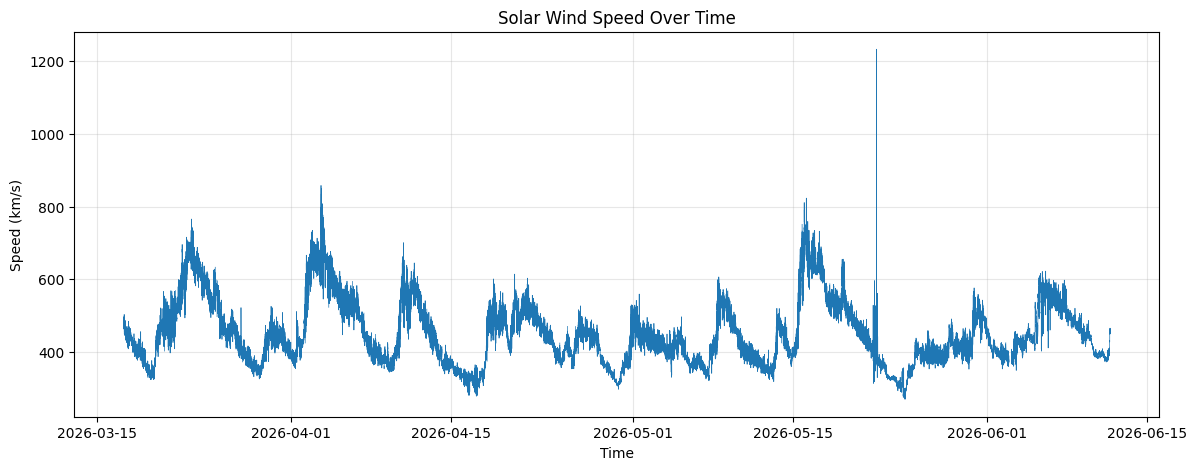

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(df_sorted["time_tag"], df_sorted["speed"], linewidth = 0.5)

plt.title("Solar Wind Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Speed (km/s)")
plt.grid(True, alpha = 0.3)

plt.show()

### Solar Wind Speed Over Time Observations

- Solar wind speed usually stays between roughly 300 and 600 km/s.
- Several high-speed intervals appear, especially around late March/early April, mid-May, and early June. 
- There is one extreme spike above 1,200 km/s around late May.
- High-speed periods may be relevant for geomagnetic storm prediction, especially if they occur together with strong southward Bz or elevated magnetic field strength.
- The extreme speed spike should be revisited during outlier analysis to determine whether it may represent a real solar wind event or a possible data artifact.

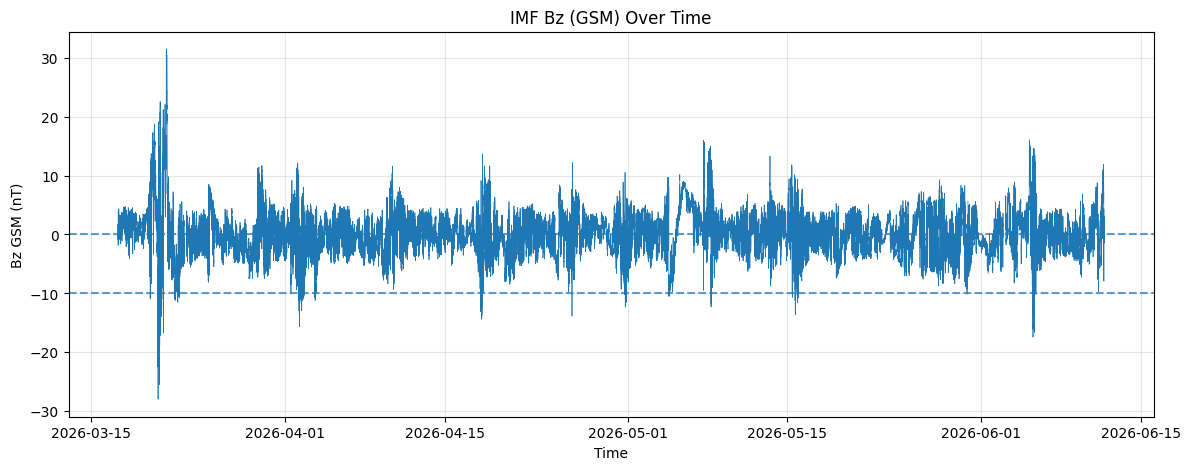

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_sorted["time_tag"], df_sorted["bz_gsm"], linewidth=0.5)

# whether Bz toward northward/positive or southward/negative
plt.axhline(0, linestyle = "--", alpha = 0.7)
# -10 is the limit that's related to moderate storm
plt.axhline(-10, linestyle = "--", alpha = 0.7)

plt.title("IMF Bz (GSM) Over Time")
plt.xlabel("Time")
plt.ylabel("Bz GSM (nT)")
plt.grid(True, alpha = 0.3)

plt.show()

### IMF Bz Over Time Observations

- `bz_gsm` fluctuates around 0 nT for much of the observed period, meaning the magnetic field orientation frequently shifts between northward and southward.
- Several periods fall below 0 nT, indicating southward Bz.
- A smaller number of readings fall below -10 nT, which may be especially relevant for geomagnetic storm prediction.
- The strongest negative Bz value appears to be near -28 nT, matching the summary statistics minimum of -27.95 nT. 
- Because sustained negative Bz is more important than a single isolated reading, future feature engineering may need to capture rolling minimum Bz, average Bz, or duration of southward Bz over time windows. 
- Bz should likely be analyzed together with speed and total magnetic field strength (`bt`) rather than alone. 

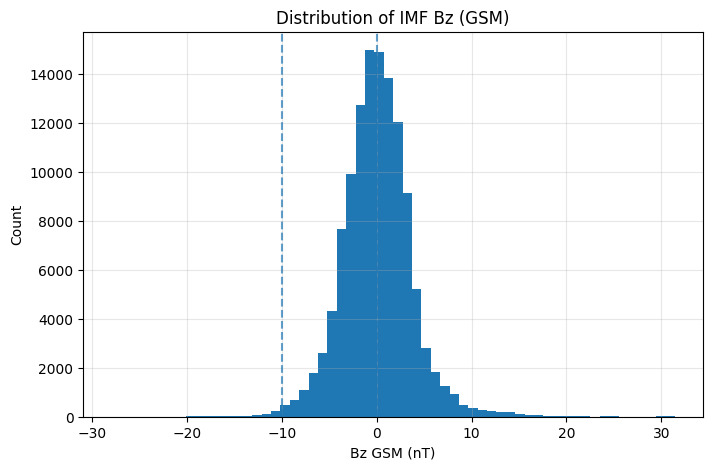

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df_sorted["bz_gsm"].dropna(), bins=60)

plt.axvline(0, linestyle="--", alpha=0.7)
plt.axvline(-10, linestyle="--", alpha=0.7)

plt.title("Distribution of IMF Bz (GSM)")
plt.xlabel("Bz GSM (nT)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)

plt.show()

### Bz Distribution Observations

- The distribution of `bz_gsm` is centered near 0 nT.
- Most Bz values fall roughly between -5 and +5 nT.
- Readings below -10 nT are relatively rare, but may be important because strong southward Bz can contribute to geomagnetic storms.
- The distribution has both negative and positive tails, showing that Bz can shift strongly in either direction.
- For modeling, it may be useful to create threshold-based features such as whether Bz is below 0 nT, below -5 nT, or below -10 nT.

## Outlier Checks

This section checks potential outliers in the numerical solar wind variables. In this dataset, extreme values should not automatically be treated as errors because they may represent physically meaningful solar wind events, such as high-speed streams or CME-related conditions. The goal is to identify unusual values for later review rather than remove them immediately.

In [24]:
outlier_summary = []

for col in numeric_cols:
    series = df_sorted[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_percent = outlier_count / len(series) * 100

    outlier_summary.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_percent, 2),
        "min": series.min(),
        "max": series.max()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df.sort_values("outlier_percent", ascending=False)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,min,max
0,density,1.37,3.97,2.60,-2.530,7.870,8313,6.93,0.00,190.63
3,bt,4.25,7.08,2.83,0.005,11.325,7499,6.20,0.20,38.97
2,temperature,49795.00,136461.50,86666.50,-80204.750,266461.250,6963,5.86,2000.00,3573881.00
6,bz_gsm,-2.12,2.13,4.25,-8.495,8.505,3805,3.15,-27.95,31.43
5,by_gsm,-3.34,2.46,5.80,-12.040,11.160,2656,2.20,-34.40,24.63
1,speed,387.60,503.60,116.00,213.600,677.600,1636,1.37,270.10,1232.70
4,bx_gsm,-2.60,2.98,5.58,-10.970,11.350,1102,0.91,-33.83,16.12


### Outlier Check Observations

- IQR-based outliers appear in all numerical measurement variables.
- `density` has the highest outlier at 6.93%, with a maximum value of 190.63 protons/cm^3.
- `bt` also has many high-end outliers, with 6.20% of readings outside the IQR bounds and a maximum of 38.97 nT.
- `temperature` has a wide range and high maximum value, suggesting a strongly right-skewed distribution.
- `speed` has fewer IQR outliers at 1.37%, but the maximum value of 1,232.7 km/s is an important extreme reading to revisit.
- `bz_gsm` has both negative and positive extremes. Negative Bz outliers may be especially important because southward Bz is a key storm driver.
- These outliers should not be automatically removed because extreme solar wind conditions may represent physically meaningful space weather events.
- For future modeling it may be better to create threshold or event-flag features rather than simply dropping outlier rows.

In [26]:
df_sorted.loc[df_sorted["speed"].idxmax()]

time_tag                  2026-05-22 07:13:00
density                                  3.14
speed                                  1232.7
temperature                         3573881.0
bt                                       3.62
bx_gsm                                   1.51
by_gsm                                   -0.2
bz_gsm                                  -3.28
missing_magnetic_count                      0
missing_plasma_count                        0
time_diff                     0 days 00:01:00
Name: 94338, dtype: object

### Extreme Speed Reading

The maximum solar wind speed occurs at 2026-05-22 07:13:00 with a speed of 1232.7 km/s. This same row also has the maximum observed temperature of 2,573,881 K, but the magnetic field variables are not extreme at that exact timestamp (`bt` = 3.62 nT, `bz_gsm` = -3.28 nT).

This suggests that extreme speed alone may not fully indicate storm-relevant conditions. For geomagnetic storm prediction, speed should likely be interpreted together with magnetic field strength, Bz direction, and duration-based features.

In [28]:
df_sorted.loc[df_sorted["bz_gsm"].idxmin()]

time_tag                  2026-03-20 21:05:00
density                                 10.79
speed                                   506.2
temperature                           51822.0
bt                                      33.69
bx_gsm                                 -14.94
by_gsm                                 -11.41
bz_gsm                                 -27.95
missing_magnetic_count                      0
missing_plasma_count                        0
time_diff                     0 days 00:01:00
Name: 5014, dtype: object

### Extreme Southward Bz Reading

The most negative Bz reading occurs at 2026-03-20 21:05:00, with `bz_gsm` = -27.95 nT. This is much lower than the -10 nT threshold discussed in the dataset description for potentially storm-relevant southward Bz.

At the same timestamp, `bt` is also very high at 33.69 nT, and density is elevated at 10.79 protons/cm^3. Unlike the maximum speed row, this row appears more directly relevant to geomagnetic storm conditions becuase it combines strong total magnetic field strength with strongly southward Bz.

This suggests that storm-relevant conditions may depend more on combinations of variables, especially `bt` and sustained negative `bz_gsm`, rather than solar wind speed alone.

## Final EDA Summary

This Solar Wind dataset contains timestamped, approximately 1-minute cadence measurements of solar wind plasma and magnetic field conditions from DSCOVR/ACE spacecraft near the L1 point. The dataset covers about 86 days of observations, from 2026-03-17 to 2026-06-11 in the current loaded version.

Key findings from this initial EDA:

- The dataset has 8 columns: one timestamp column and seven numerical measurement variables.
- `time_tag` is complete with no missing values, which is important for future time-based merging with geomagnetic storm labels or indices.
- All measurement variables have some missing data, but missing percentages are relatively low.
- Magnetic field variables (`bt`, `bx_gsm`, `by_gsm`, `bz_gsm`) appear to be missing together, suggesting shared instrument/source availability.
- Plasma variables (`density`, `speed`, `temperature`) show more varied missingness patterns.
- The dataset is mostly recorded at 1-minute cadence, but there are some timestamp gaps, including one major gap of 5 hours and 30 minutes.
- Solar wind speed usually stays around quiet-to-moderate levels, but there are several high-speed periods and one extreme speed spike above 1,200 km/s.
- `bz_gsm` is centered near 0 nT but includes important negative extremes. Readings below -10 nT are relatively rare but may be highly relevant for geomagnetic storm prediction.
- IQR-based outliers appear in all numerical variables. These should not be automatially removed because extreme values may represent physically meaningful solar wind events.
- The most negative Bz reading combines strongly southward Bz with high total magnetic field strength, making it more storm-relevant than the maximum speed reading alone.

## Questions for Further Research

To better prepare this dataset for modeling, investigate:

1. What target label should define a geomagnetic storm?
    - Possible options include Kp index threshold, Dst index threshold, or storm event labels from another dataset.

2. What time lag should be used between L1 solar wind measurements and storm effects at Earth?
    - The dataset description suggests that L1 measurements may provide roughly 15-60 minutes of lead time before solar wind reaches Earth.

3. How should missing time gaps be handled?
    - Options may include leaving gaps as-is, resampling to a regular 1-minute grid, interpolation for short gaps, or adding missingness indicators.

4. How should extreme values be treated?
    - Extreme values may represent real space weather events rather than data errors, so they should be reviewed before removal.

5. What engineered features may be useful?
    - Rolling mean/minimum of `bz_gsm`
    - Duration of southward Bz (`bz_gsm < 0`)
    - Duration of strong southward Bz (`bz_gsm < -10`)
    - Rolling maximum speed
    - Rolling maximum `bt`
    - Combined features such as high speed + negative Bz or high `bt` + negative Bz

6. Which variables are most important based on space weather domain knowledge?
    - `bz_gsm` appears especially important because sustained negative Bz can couple with Earth's magnetosphere.
    - `bt`, `speed`, and `density` may also be important when combined with Bz.

## Potential Feature for Final Model

Potential raw variables:
- `density`
- `speed`
- `temperature`
- `bt`
- `bx_gsm`
- `by_gsm`
- `bz_gsm`

Potential engineered variables:
- rolling average solar wind speed over previous 30/60/180 minutes
- rolling minimum `bz_gsm` over previous 30/60/180 minutes
- rolling maximum `bt` over previous 30/60/180 minutes
- count or duration of readings where `bz_gsm < 0`
- count or duration of readings where `bz_gsm < -10`
- indicator for high-speed solar wind
- indicator for high `bt`
- interaction feature: high speed and negative Bz
- interaction feature: high `bt` and negative Bz